<a href="https://colab.research.google.com/github/iandrukhiv-cell/addressbook-python/blob/main/%D0%9A%D0%BE%D0%BF%D1%96%D1%8F_%D0%B7%D0%B0%D0%BF%D0%B8%D1%81%D0%BD%D0%B8%D0%BA%D0%B0_%22%D0%90%D0%BD%D0%B4%D1%80%D1%83%D1%85%D1%96%D0%B2_%D0%86%D0%BB%D0%BE%D0%BD%D0%B0_%D0%92%D0%BE%D0%BB%D0%BE%D0%B4%D0%B8%D0%BC%D0%B8%D1%80%D1%96%D0%B2%D0%BD%D0%B0_%D0%9E%D1%81%D0%BD%D0%BE%D0%B2%D0%B8_%D0%B0%D0%BD%D0%B0%D0%BB%D1%96%D1%82%D0%B8%D0%BA%D0%B8_%D0%94%D0%973%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Завдання №1

**Задача №1**

Прочитайте дані за допомогою методу read_html з таблиці "Коефіцієнт народжуваності в регіонах України (1950—2019)".

Імпорт бібліотек і зчитування таблиці з сайту

In [ ]:
import pandas as pd
import requests
from io import StringIO

url = "https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8#%D0%9D%D0%B0%D1%80%D0%BE%D0%B4%D0%B6%D1%83%D0%B2%D0%B0%D0%BD%D1%96%D1%81%D1%82%D1%8C"

headers = {
    "User-Agent": "Mozilla/5.0"
}




Зчитування даних з сайту

In [ ]:
response = requests.get(url, headers=headers)

tables = pd.read_html(StringIO(response.text))

len(tables)

70

Виведення перших рядків таблиці

In [ ]:
df = tables[13]
df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,—,—
1,Вінницька,224.0,192.0,142.0,124,84,112,109,76
2,Волинська,247.0,250.0,179.0,153,112,148,141,101
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111,71
4,Донецька,271.0,214.0,140.0,109,61,98,82,—


Визначення розміру датафрейму

In [ ]:
df.shape

(28, 9)

Перегляд назв стовпців

In [ ]:
df.columns

Index(['Регіон', '1950', '1960', '1970', '1990', '2000', '2012', '2014',
       '2019'],
      dtype='object')

Заміна пропусків на NaN

In [ ]:
import numpy as np
df = df.replace("—", np.nan)

Перевірка типів даних

In [ ]:
df.dtypes

,0
Регіон,object
1950,float64
1960,float64
1970,float64
1990,int64
2000,int64
2012,int64
2014,object
2019,object


Перетворення числових стовпців у формат числа

In [ ]:
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

Підрахунок кількості пропусків у кожному стовпці

In [ ]:
df.isnull().sum()

,0
Регіон,0
1950,2
1960,1
1970,1
1990,0
2000,0
2012,0
2014,2
2019,4


Видалення останнього рядка з даними по всій країні

In [ ]:
df = df.iloc[:-1]

Заповнення пропусків середніми значеннями

In [ ]:
df = df.fillna(df.mean(numeric_only=True))
df.isnull().sum()

,0
Регіон,0
1950,0
1960,0
1970,0
1990,0
2000,0
2012,0
2014,0
2019,0


Пошук регіонів, де рівень народжуваності у 2019 році вищий за середній

In [ ]:
avg_2019 = df["2019"].mean()

df[df["2019"] > avg_2019]["Регіон"]

,Регіон
2,Волинська
6,Закарпатська
8,Івано-Франківська
12,Львівська
14,Одеська
16,Рівненська
20,Херсонська
23,Чернівецька
25,Київ


Пошук регіону з найвищою народжуваністю у 2014 році

In [ ]:
df.loc[df["2014"].idxmax(), "Регіон"]

'Рівненська'

Відповідь: регіон з найвищою народжуваністю у 2014 році

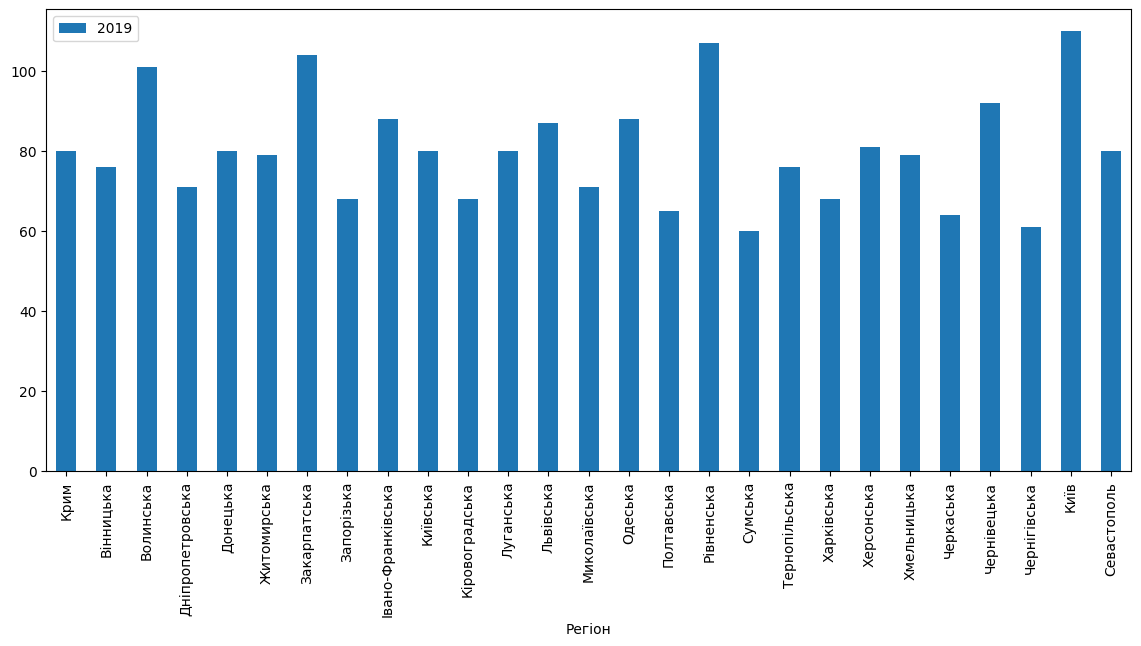

In [ ]:
import matplotlib.pyplot as plt

df.plot(x="Регіон", y="2019", kind="bar", figsize=(14,6))
plt.show()

Візуалізація народжуваності по регіонах у 2019 році

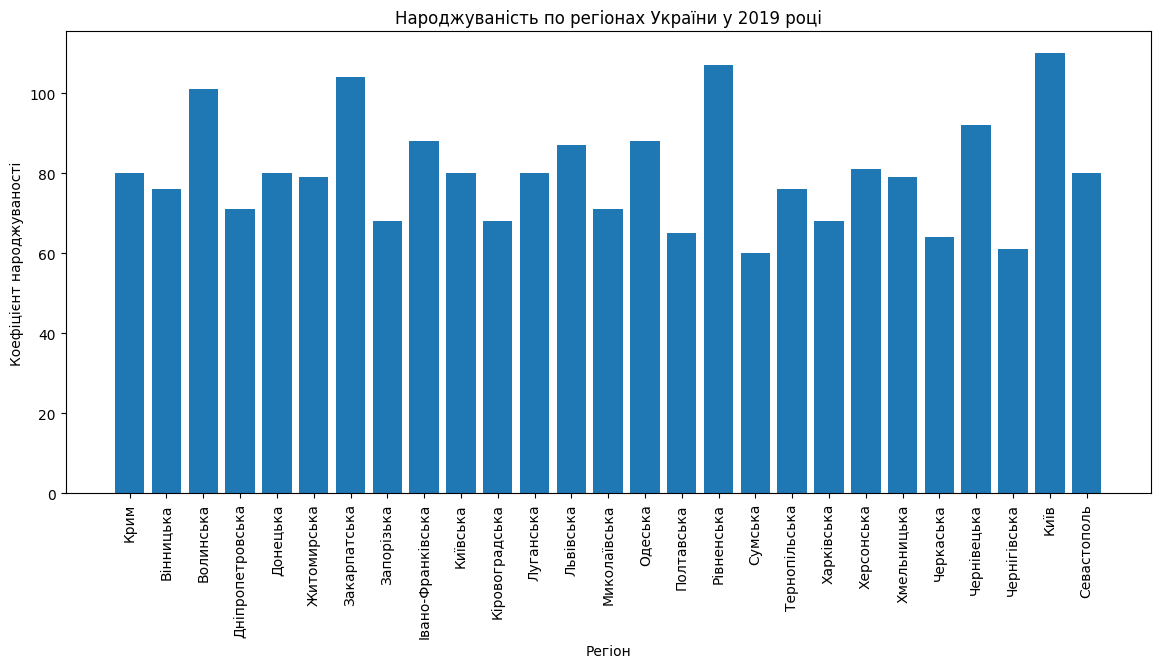

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.bar(df["Регіон"], df["2019"])

plt.title("Народжуваність по регіонах України у 2019 році")
plt.xlabel("Регіон")
plt.ylabel("Коефіцієнт народжуваності")
plt.xticks(rotation=90)

plt.show()

**Задача №2**

Проведіть аналіз файлу 2017_jun_final.csv.

Зчитування CSV файлу

In [ ]:
import pandas as pd
import os

# шукаємо файл по всьому Colab
for root, dirs, files in os.walk("/"):
    if "2017_jun_final.csv" in files:
        file_path = os.path.join(root, "2017_jun_final.csv")
        break

print(file_path)

df = pd.read_csv(file_path)
df.head()

/2017_jun_final.csv


,N,Посада,Мова.програмування,Спеціалізація,Загальний.досвід.роботи,Досвід.роботи.на.поточному.місці,Зарплата.на.місяць,Зміна.зарплати.за.12.місяців,Місто,Розмір.компанії,...,Ще.студент,Рівень.англійської,Предметна.область,Дата.заповнення,User.Agent,exp,current_job_exp,salary,Валюта,cls
0,1,Junior QA engineer,NaN,Manual QA,0.5,0.5,400,0,Харків,до 10 осіб,...,True,нижче середнього,"iOS,eCommerce",12/06/2017 12:38:08,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0.5,0.5,400,NaN,QA
1,2,Junior QA engineer,NaN,Manual QA,менше 3 місяців,менше 3 місяців,430,130,Харків,понад 1000 осіб,...,True,вище середнього,Веб-розробка,12/06/2017 12:42:51,Mozilla/5.0 (iPad; CPU OS 10_2_1 like Mac OS X...,0.0,0.0,430,NaN,QA
2,3,Software Engineer,C#/.NET,NaN,4,1,2500,800,Київ,до 1000 осіб,...,False,середній,"Веб-розробка,Корпоративні системи",12/06/2017 13:02:47,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,4.0,1.0,2500,NaN,DEV
3,4,Software Engineer,JavaScript,NaN,5,4,2000,400,Одеса,до 200 осіб,...,False,нижче середнього,"Desktop Applications,Веб-розробка",12/06/2017 13:03:01,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,5.0,4.0,2000,NaN,DEV
4,5,Senior Software Engineer,JavaScript,NaN,10 і більше років,0.5,4500,500,Інше,до 10 осіб,...,False,середній,"Desktop Applications,Веб-розробка",12/06/2017 13:03:47,Mozilla/5.0 (iPhone; CPU iPhone OS 10_3_2 like...,10.0,0.5,4500,NaN,DEV


Визначення розміру датафрейму

In [ ]:
df.shape

(8704, 25)

Перевірка типів даних

In [ ]:
df.dtypes

,0
N,int64
Посада,object
Мова.програмування,object
Спеціалізація,object
Загальний.досвід.роботи,object
Досвід.роботи.на.поточному.місці,object
Зарплата.на.місяць,int64
Зміна.зарплати.за.12.місяців,int64
Місто,object
Розмір.компанії,object


Підрахунок кількості пропусків у кожному стовпці

In [ ]:
df.isnull().sum()

,0
N,0
Посада,0
Мова.програмування,3850
Спеціалізація,7219
Загальний.досвід.роботи,0
Досвід.роботи.на.поточному.місці,0
Зарплата.на.місяць,0
Зміна.зарплати.за.12.місяців,0
Місто,0
Розмір.компанії,0


Видалення стовпців з пропусками (крім "Мова.програмування")

In [ ]:
cols_without_nan = df.columns[df.isnull().sum() == 0]

df = df[cols_without_nan.tolist() + ["Мова.програмування"]]

Повторна перевірка пропусків

In [ ]:
df.isnull().sum()

,0
N,0
Посада,0
Загальний.досвід.роботи,0
Досвід.роботи.на.поточному.місці,0
Зарплата.на.місяць,0
Зміна.зарплати.за.12.місяців,0
Місто,0
Розмір.компанії,0
Тип.компанії,0
Стать,0


Визначення нового розміру датафрейму

In [ ]:
df.shape

(8704, 20)

Створення таблиці з розробниками Python

In [ ]:
python_data = df[df["Мова.програмування"] == "Python"]

Визначення розміру таблиці python_data

In [ ]:
python_data.shape

(207, 20)

Групування за посадою

In [ ]:
python_data.groupby("Посада")

Мінімальна та максимальна зарплата за посадою

In [ ]:
salary_stats = python_data.groupby("Посада")["salary"].agg(["min", "max"])
salary_stats

,min,max
Посада,,
Junior Software Engineer,100,1250
Senior Software Engineer,1300,9200
Software Engineer,500,5400
System Architect,3000,5000
Technical Lead,1425,6200


Функція для обчислення середньої зарплати

In [ ]:
def fill_avg_salary(row):
    return row["salary"]

Додавання нового стовпця avg

In [ ]:
python_data["avg"] = python_data.apply(fill_avg_salary, axis=1)

/tmp/ipykernel_2183/3206084773.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  python_data["avg"] = python_data.apply(fill_avg_salary, axis=1)


Описова статистика для стовпця avg

In [ ]:
python_data["avg"].describe()

,avg
count,207.000000
mean,1753.937198
std,1314.751537
min,100.000000
25%,750.000000
50%,1425.000000
75%,2500.000000
max,9200.000000


Побудова стовпчикового графіка мінімальної та максимальної зарплати

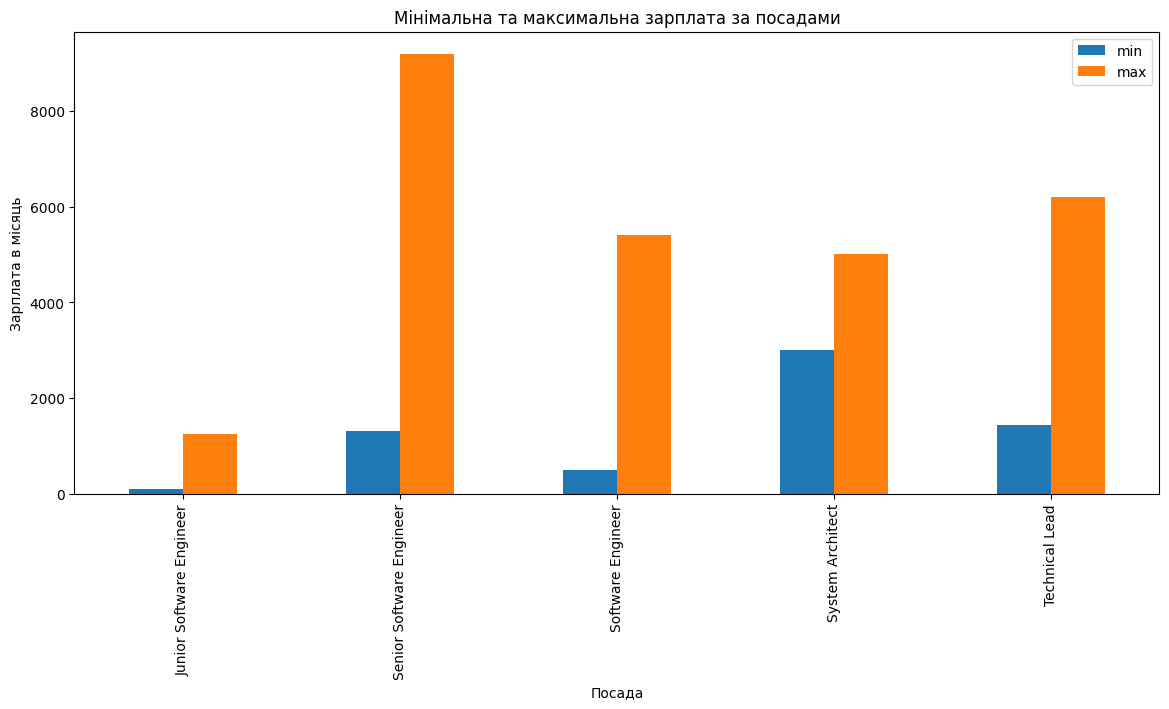

In [ ]:
import matplotlib.pyplot as plt

salary_stats.plot(kind="bar", figsize=(14, 6))

plt.title("Мінімальна та максимальна зарплата за посадами")
plt.xlabel("Посада")
plt.ylabel("Зарплата в місяць")
plt.xticks(rotation=90)

plt.show()

 Збереження результатів у CSV файл

In [ ]:
python_data.to_csv("result.csv", index=False)

**Задача №3**

Аналіз датасету з kaggle.com

Зчитування датасету

In [ ]:
import pandas as pd
import os

file_path = None

for root, dirs, files in os.walk("/"):
    if "bestsellers with categories.csv" in files:
        file_path = os.path.join(root, "bestsellers with categories.csv")
        break

print(file_path)

df = pd.read_csv(file_path)
df.head()

/bestsellers with categories.csv


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


Скільки книг у датасеті

In [ ]:
df.shape

(550, 7)

**Відповідь: у датасеті 550 книг**

Приведення назв колонок до зручного формату (snake_case)

In [ ]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

Перевірка наявності пропусків у даних

In [ ]:
df.isna().sum()

,0
name,0
author,0
user_rating,0
reviews,0
price,0
year,0
genre,0


**Відповідь: пропусків у датасеті немає**

Визначення унікальних значень у колонці genre

In [ ]:
df["genre"].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

**Відповідь: Fiction, Non Fiction**

Побудова гістограми розподілу цін

<Axes: ylabel='Frequency'>

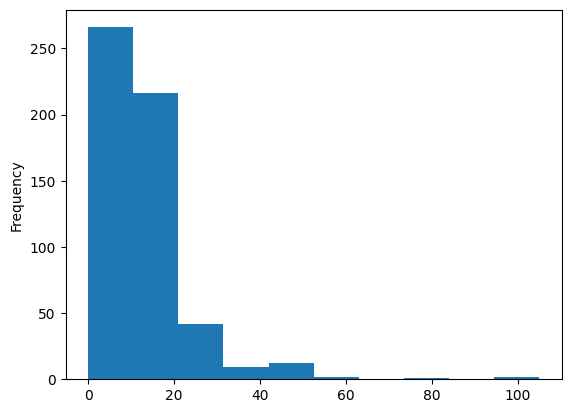

In [ ]:
df["price"].plot(kind="hist")

Обчислення статистичних показників ціни

In [ ]:
max_price = df["price"].max()
min_price = df["price"].min()
mean_price = df["price"].mean()
median_price = df["price"].median()

max_price, min_price, mean_price, median_price

(105, 0, np.float64(13.1), 11.0)

**Відповідь: максимальна ціна — 105  
Відповідь: мінімальна ціна — 0  
Відповідь: середня ціна — 13.1  
Відповідь: медіанна ціна — 11**

Визначення максимального рейтингу

In [ ]:
df["user_rating"].max()

4.9

**Відповідь: максимальний рейтинг — 4.9**

Кількість книг з максимальним рейтингом

In [ ]:
df[df["user_rating"] == df["user_rating"].max()].shape[0]

52

**Відповідь: 52 книги мають максимальний рейтинг**

Книга з найбільшою кількістю відгуків

In [ ]:
df.loc[df["reviews"].idxmax()]

,534
name,Where the Crawdads Sing
author,Delia Owens
user_rating,4.8
reviews,87841
price,15
year,2019
genre,Fiction


**Відповідь: Where the Crawdads Sing має найбільшу кількість відгуків**

Визначення найдорожчої книги у 2015 році

In [ ]:
df_2015 = df[df["year"] == 2015]
df_2015.loc[df_2015["price"].idxmax()]

,277
name,Publication Manual of the American Psychologic...
author,American Psychological Association
user_rating,4.5
reviews,8580
price,46
year,2015
genre,Non Fiction


**Відповідь: найдорожча книга — Publication Manual of the American Psychological Association**

Кількість книг жанру Fiction у 2010 році

In [ ]:
df[(df["year"] == 2010) & (df["genre"] == "Fiction")].shape[0]

20

**Відповідь: 20 книг жанру Fiction**

Кількість книг з рейтингом 4.9 у 2010 та 2011 роках

In [ ]:
df[(df["user_rating"] == 4.9) & (df["year"].isin([2010, 2011]))].shape[0]

1

**Відповідь: 1 книга**

Сортування книг дешевше 8$ у 2015 році

In [ ]:
filtered = df[(df["year"] == 2015) & (df["price"] < 8)]
filtered_sorted = filtered.sort_values(by="price")

filtered_sorted

,name,author,user_rating,reviews,price,year,genre
507,To Kill a Mockingbird,Harper Lee,4.8,26234,0,2015,Fiction
54,Creative Haven Creative Cats Coloring Book (Ad...,Marjorie Sarnat,4.8,4022,4,2015,Non Fiction
206,Knock-Knock Jokes for Kids,Rob Elliott,4.5,3673,4,2015,Non Fiction
111,First 100 Words,Roger Priddy,4.7,17323,4,2015,Non Fiction
210,Laugh-Out-Loud Jokes for Kids,Rob Elliott,4.6,6990,4,2015,Non Fiction
123,Giraffes Can't Dance,Giles Andreae,4.8,14038,4,2015,Fiction
55,Creative Haven Owls Coloring Book (Adult Color...,Marjorie Sarnat,4.8,3871,5,2015,Non Fiction
63,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2015,Fiction
224,Love You Forever,Robert Munsch,4.8,18613,5,2015,Fiction
478,The Very Hungry Caterpillar,Eric Carle,4.9,19546,5,2015,Fiction


Визначення останньої книги у відсортованому списку

In [ ]:
filtered_sorted.tail(1)

,name,author,user_rating,reviews,price,year,genre
253,Old School (Diary of a Wimpy Kid #10),Jeff Kinney,4.8,6169,7,2015,Fiction


**Відповідь: остання книга у відсортованому списку — Old School (Diary of a Wimpy Kid #10)**

Аналіз розподілу книг за жанрами

In [ ]:
avg_rating = df.groupby("genre")["user_rating"].mean()
avg_rating

,user_rating
genre,
Fiction,4.648333
Non Fiction,4.595161


Візуалізація середнього рейтингу за жанрами


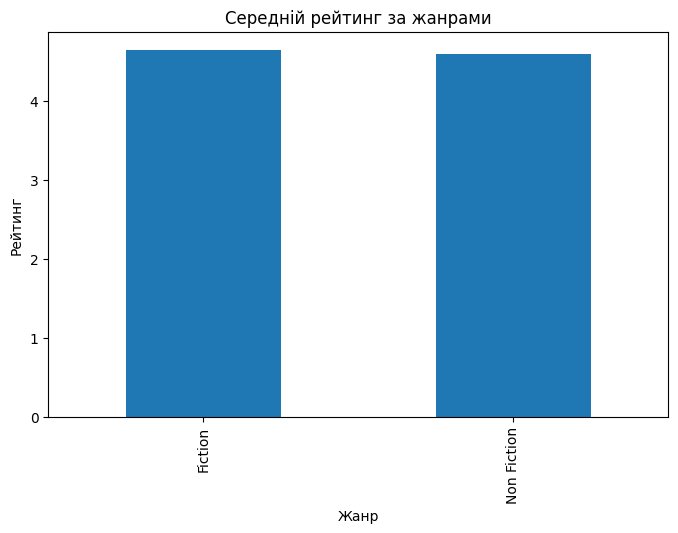

In [ ]:
import matplotlib.pyplot as plt

avg_rating.plot(kind="bar", figsize=(8, 5))

plt.title("Середній рейтинг за жанрами")
plt.xlabel("Жанр")
plt.ylabel("Рейтинг")

plt.show()

середня ціна + кількість книг по жанрах

In [ ]:
genre_price_stats = df.groupby("genre").agg({
    "price": "mean",
    "name": "count"
}).rename(columns={
    "price": "Середня ціна",
    "name": "Кількість книг"
})

genre_price_stats

,Середня ціна,Кількість книг
genre,,
Fiction,10.850000,240
Non Fiction,14.841935,310


# Завдання №2

Було реалізовано алгоритм побудови візерунку Серпінського методом випадкових точок.
На кожному кроці обирається випадкова вершина трикутника, після чого нова точка визначається як середина між поточною точкою та вибраною вершиною.

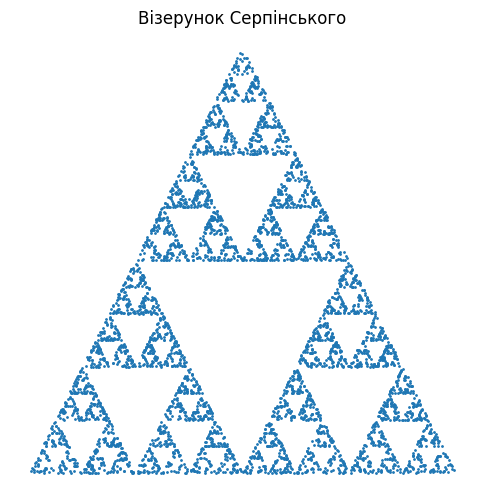

In [ ]:
import random
import matplotlib.pyplot as plt

# вершини трикутника
x = [0, 1, 0.5]
y = [0, 0, 0.866]

# стартова точка
px, py = 0.25, 0.25

points_x = []
points_y = []

# генеруємо точки
for _ in range(5000):
    i = random.randint(0, 2)
    px = (px + x[i]) / 2
    py = (py + y[i]) / 2

    points_x.append(px)
    points_y.append(py)

# малюємо
plt.figure(figsize=(6,6))
plt.scatter(points_x, points_y, s=1)
plt.title("Візерунок Серпінського")
plt.axis("off")

plt.show()

# Завдання №3


Аналіз залежності прибутковості акцій A, B та C

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

stocks = pd.DataFrame({
    "A": [25, -10, 10, 5, 35, 13],
    "B": [0, 15, -5, 5, 20, 25],
    "C": [10, 25, -15, -5, -5, 15]
})

stocks

,A,B,C
0,25,0,10
1,-10,15,25
2,10,-5,-15
3,5,5,-5
4,35,20,-5
5,13,25,15


Графік 1: залежність прибутковості акції B від акції A

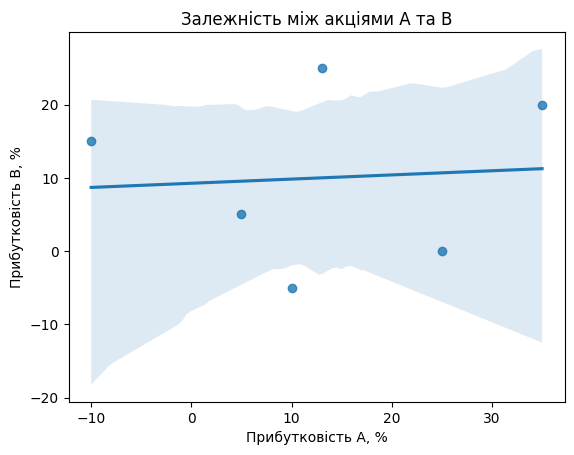

In [ ]:
sns.regplot(x="A", y="B", data=stocks)
plt.title("Залежність між акціями A та B")
plt.xlabel("Прибутковість A, %")
plt.ylabel("Прибутковість B, %")
plt.show()

Графік 2: залежність прибутковості акції C від акції A

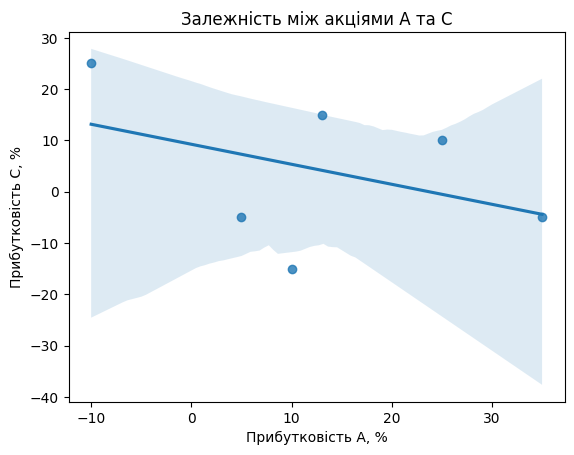

In [ ]:
sns.regplot(x="A", y="C", data=stocks)
plt.title("Залежність між акціями A та C")
plt.xlabel("Прибутковість A, %")
plt.ylabel("Прибутковість C, %")
plt.show()

Графік 3: залежність прибутковості акції C від акції B

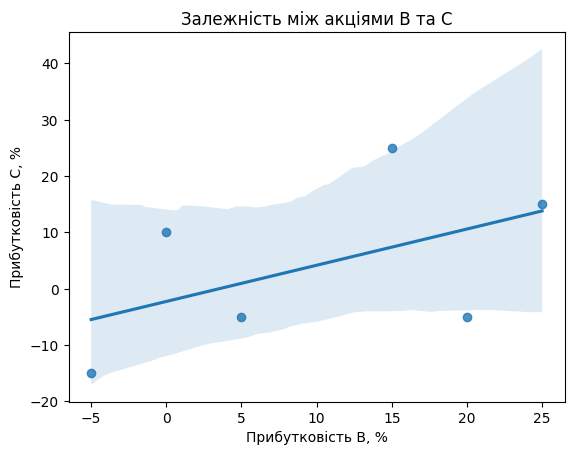

In [ ]:
sns.regplot(x="B", y="C", data=stocks)
plt.title("Залежність між акціями B та C")
plt.xlabel("Прибутковість B, %")
plt.ylabel("Прибутковість C, %")
plt.show()

Обчислення кореляції між акціями

In [ ]:
stocks.corr()

,A,B,C
A,1.000000,0.075439,-0.408807
B,0.075439,1.000000,0.508034
C,-0.408807,0.508034,1.000000


**Найменш залежною є пара акцій A та B, оскільки їх коефіцієнт кореляції найближчий до нуля.**